# Introduction to Deep Learning '26 Assignment A0

Paul Tielens, s3612031

In [1]:
import torch
import numpy as np

print(torch.cuda.is_available()) 
print(torch.cuda.device_count()) 
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 4060


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

In [3]:
# constants

nr_digits = 10

data_folder = "data/"

In [4]:
# Load data
train_in = np.loadtxt(data_folder + "train_in.csv", delimiter=",")
train_out = np.loadtxt(data_folder + "train_out.csv", delimiter=",")

test_out = np.loadtxt(data_folder + "test_out.csv", delimiter=",")
test_in = np.loadtxt(data_folder + "test_in.csv", delimiter=",")


In [5]:
values, counts = np.unique(test_out, return_counts=True)
for value, count in zip(values, counts):
    print(f"{int(value)}: {count}")

# test data is a bit unbalanced
# train data probably also

0: 224
1: 121
2: 101
3: 79
4: 86
5: 55
6: 90
7: 64
8: 92
9: 88


# Task 1.1

We would expect that digits with similar average vectors would be the most difficult to separate

In [6]:
# Calculate average vector for every digit from the training data
avg_vectors = []

for i in range(nr_digits):
    indices = np.where(train_out == i)

    vectors_i = train_in[indices]
    avg_vector_i = np.mean(vectors_i, axis=0)

    avg_vectors.append(avg_vector_i)

avg_vectors = np.array(avg_vectors)

## Distance Matrix

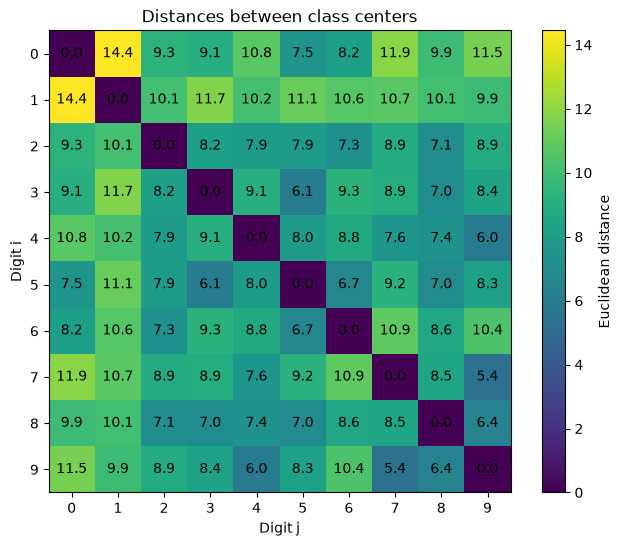

In [7]:
import matplotlib.pyplot as plt

dist_matrix = np.zeros((nr_digits, nr_digits))

c_i, c_j = 0, 0

for c_i in range(0, nr_digits - 1): # loop over 10 digit averages
    for c_j in range(c_i + 1, nr_digits):
        
        distance = np.linalg.norm(avg_vectors[c_i] - avg_vectors[c_j])
        dist_matrix[c_i][c_j] = distance
        dist_matrix[c_j][c_i] = distance
# create plot
plt.figure(figsize=(8,6))
plt.imshow(dist_matrix, cmap="viridis")
plt.colorbar(label="Euclidean distance")

for i in range(nr_digits):
    for j in range(nr_digits):
        plt.text(j, i, f"{dist_matrix[i, j]:.1f}", ha="center", va="center", fontsize=10)

plt.xticks(range(nr_digits))
plt.yticks(range(nr_digits))
plt.xlabel("Digit j")
plt.ylabel("Digit i")
plt.title("Distances between class centers")
plt.savefig("plots/distance_matrix_digit_centers.png")
plt.show()



# Task 1.2: dimensionality reduction

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

/home/s3611957/idl_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
train_in.shape

(1707, 256)

## PCA

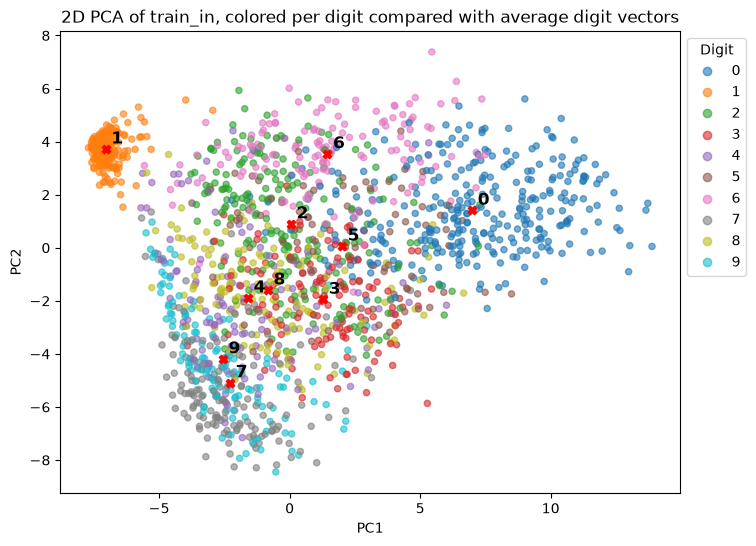

In [10]:
pca = PCA(n_components=2, random_state=42)
train_pca = pca.fit_transform(train_in)
avg_train_pca = pca.transform(avg_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_train_pca[:, 0], avg_train_pca[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_train_pca[n, 0], avg_train_pca[n, 1]),
    xytext=(4, 4), textcoords="offset points", fontsize=12, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/pca_digits.png")
plt.show()



## t-SNE

In [11]:
combined_data = np.vstack([train_in, avg_vectors])
combined_data.shape
print(combined_data.dtype)

float64


In [12]:
avg_vectors.shape

(10, 256)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1717 samples in 0.000s...
[t-SNE] Computed neighbors for 1717 samples in 0.046s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1717
[t-SNE] Computed conditional probabilities for sample 1717 / 1717
[t-SNE] Mean sigma: 2.680450
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.323868
[t-SNE] KL divergence after 1000 iterations: 0.993696


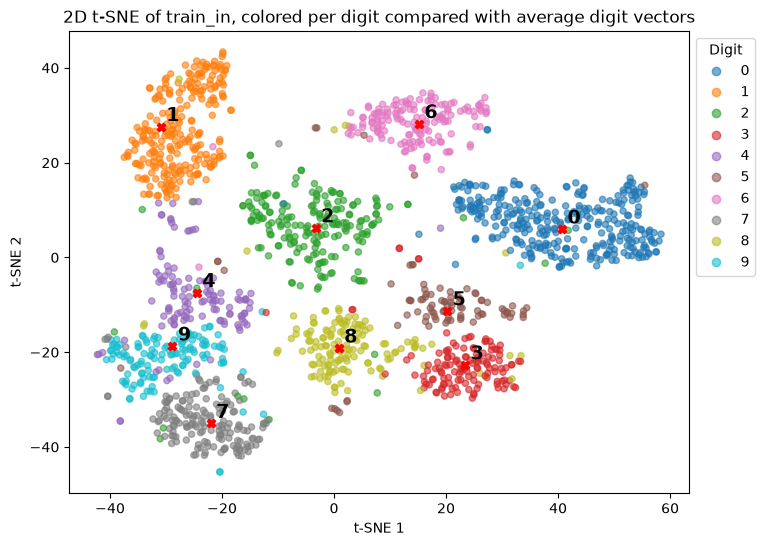

In [13]:
from threadpoolctl import threadpool_limits
# combined_data = np.vstack([train_in, avg_vectors])

tsne = TSNE(n_components=2, random_state=42, n_jobs=1, verbose=1)
with threadpool_limits(limits=1):
    combined_tsne = tsne.fit_transform(combined_data)

train_tsne = combined_tsne[:len(train_in)]
avg_tsne = combined_tsne[len(train_in):]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_tsne[:, 0], train_tsne[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_tsne[:, 0], avg_tsne[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_tsne[n, 0], avg_tsne[n, 1]), 
                 xytext=(4, 4), textcoords="offset points",fontsize=14, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("2D t-SNE of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/tsne_digits.png")
plt.show()




## U-MAP

/home/s3611957/idl_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


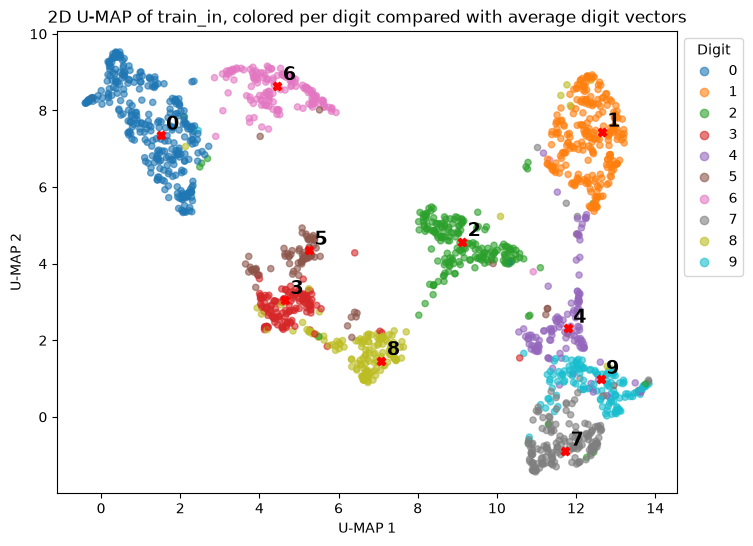

In [14]:
reducer = umap.UMAP(random_state=42)

with threadpool_limits(limits=1):
    train_umap = reducer.fit_transform(train_in)
    avg_umap = reducer.transform(avg_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(train_umap[:, 0], train_umap[:, 1], c=train_out, cmap="tab10", s=20, alpha=0.6)
plt.scatter(avg_umap[:, 0], avg_umap[:, 1], c="r", marker="X")

for n in range(nr_digits):
    plt.annotate(str(n), (avg_umap[n, 0], avg_umap[n, 1]),
    xytext=(4, 4), textcoords="offset points", fontsize=14, fontweight='bold')

plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("U-MAP 1")
plt.ylabel("U-MAP 2")
plt.title("2D U-MAP of train_in, colored per digit compared with average digit vectors")
plt.savefig("plots/umap_digits.png")
plt.show()


# Task 1.3: Nearest mean

In [15]:
# Classify the digits based on the distance between the average vector and the test vector


# training run
nm_predictions_train = []

for train_in_element in train_in:
    distances = []
    for i in range(nr_digits):
        dist = np.linalg.norm(avg_vectors[i] - train_in_element)
        distances.append(dist)

    # Take the index of the digit with the lowest 'distance'
    nm_predictions_train.append(np.argmin(distances))

vector_avg_accuracy_train = (train_out == nm_predictions_train).mean()

# test run
nm_predictions_test = []


for test_in_element in test_in:
    distances = []
    for i in range(nr_digits):
        dist = np.linalg.norm(avg_vectors[i] - test_in_element)
        distances.append(dist)

    # Take the index of the digit with the lowest 'distance'
    nm_predictions_test.append(np.argmin(distances))

vector_avg_accuracy_test = (test_out == nm_predictions_test).mean()

print(f"Nearest mean training set accuracy: {vector_avg_accuracy_train:.3f} = {vector_avg_accuracy_train * 100:.1f}%")
print(f"Nearest mean test set accuracy: {vector_avg_accuracy_test:.3f} = {vector_avg_accuracy_test * 100:.1f}%")

Nearest mean training set accuracy: 0.864 = 86.4%
Nearest mean test set accuracy: 0.804 = 80.4%


# Task 1.4: KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
neigh = KNeighborsClassifier(n_neighbors=3)

with threadpool_limits(limits=1):
    neigh.fit(train_in, train_out)
    knn_predictions_train = neigh.predict(train_in)
    knn_predictions_test = neigh.predict(test_in)

accuracy_train = (train_out == knn_predictions_train).mean()
accuracy_test = (test_out == knn_predictions_test).mean()

print(f"KNN training set accuracy: {accuracy_train:.3f} = {accuracy_train * 100:.1f}%")
print(f"KNN test set accuracy: {accuracy_test:.3f} = {accuracy_test * 100:.1f}%")

KNN training set accuracy: 0.979 = 97.9%
KNN test set accuracy: 0.914 = 91.4%


## Confusion Matrices
Both CF's for nearest mean and KNN are built on test set predictions

In [22]:
cf_nearestmean = np.zeros((nr_digits, nr_digits))
cf_knn = np.zeros((nr_digits, nr_digits))

nm_predictions_test = np.array(nm_predictions_test)
knn_predictions_test = np.array(knn_predictions_test)

c_i, c_j = 0, 0

for c_i in range(nr_digits):
    for c_j in range(nr_digits):
        # counts of digits i classified as j for both algorithms
        c_ij_nm = np.sum((test_out == c_i) & (nm_predictions_test == c_j))
        c_ij_knn = np.sum((test_out == c_i) & (knn_predictions_test == c_j))
        # update confusion matrices
        cf_nearestmean[c_i][c_j] = c_ij_nm
        cf_knn[c_i][c_j] = c_ij_knn

In [23]:
cf_knn

array([[219.,   0.,   2.,   0.,   1.,   0.,   1.,   0.,   0.,   1.],
       [  0., 119.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.],
       [  6.,   2.,  87.,   1.,   0.,   0.,   1.,   1.,   3.,   0.],
       [  4.,   0.,   1.,  70.,   0.,   2.,   0.,   0.,   0.,   2.],
       [  0.,   2.,   1.,   0.,  78.,   1.,   0.,   1.,   0.,   3.],
       [  5.,   0.,   0.,   9.,   1.,  37.,   0.,   0.,   0.,   3.],
       [  2.,   1.,   0.,   0.,   1.,   0.,  86.,   0.,   0.,   0.],
       [  0.,   3.,   0.,   1.,   3.,   0.,   0.,  56.,   0.,   1.],
       [  1.,   2.,   0.,   4.,   1.,   0.,   1.,   2.,  79.,   2.],
       [  1.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   1.,  83.]])

In [24]:
from sklearn.metrics import confusion_matrix

# alternative sklearn implementation
nm_cf = confusion_matrix(test_out, nm_predictions_test)
knn_cf = confusion_matrix(test_out, knn_predictions_test)

print(np.array_equal(knn_cf, cf_knn))
print(np.array_equal(nm_cf, cf_nearestmean))

True
True


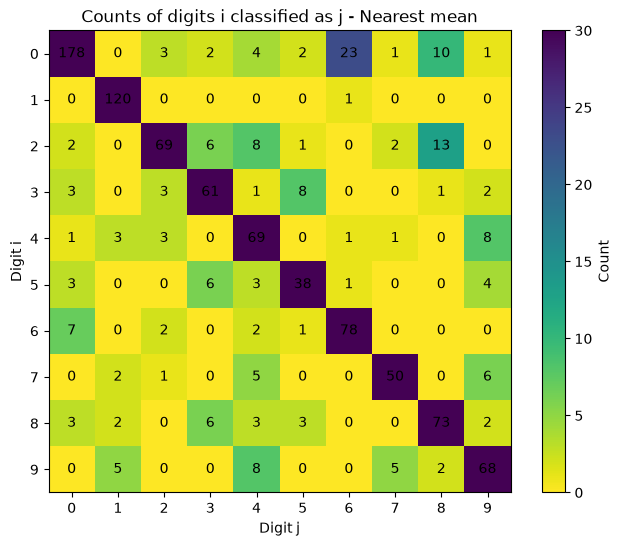

In [47]:
# create plot
plt.figure(figsize=(8,6))
plt.imshow(nm_cf, cmap="viridis_r", vmax=30)
plt.colorbar(label="Count")

for i in range(nr_digits):
    for j in range(nr_digits):
        plt.text(j, i, f"{nm_cf[i, j]}", ha="center", va="center", fontsize=10)

plt.xticks(range(nr_digits))
plt.yticks(range(nr_digits))
plt.xlabel("Digit j")
plt.ylabel("Digit i")
plt.title("Counts of digits i classified as j - Nearest mean")
plt.savefig("plots/nearestmean_cf.png")
plt.show()

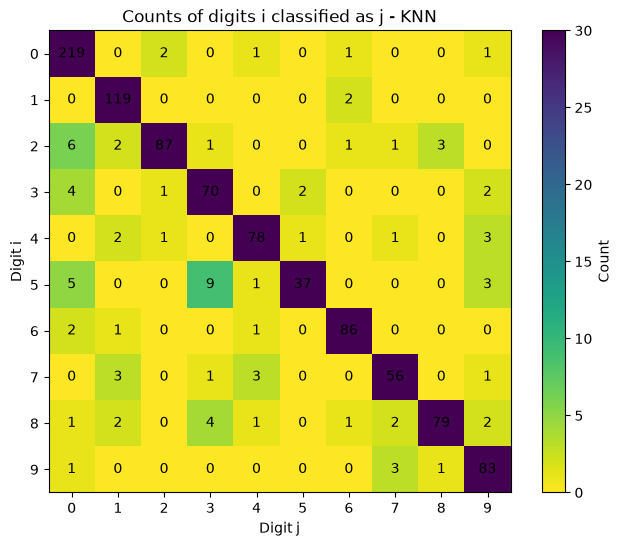

In [48]:
# create plot
plt.figure(figsize=(8,6))
plt.imshow(knn_cf, cmap="viridis_r", vmax=30)
plt.colorbar(label="Count")

for i in range(nr_digits):
    for j in range(nr_digits):
        plt.text(j, i, f"{knn_cf[i, j]}", ha="center", va="center", fontsize=10)

plt.xticks(range(nr_digits))
plt.yticks(range(nr_digits))
plt.xlabel("Digit j")
plt.ylabel("Digit i")
plt.title("Counts of digits i classified as j - KNN")
plt.savefig("plots/knn_cf.png")
plt.show()

# Task 2: Multi-Layer Perceptron

In [100]:
lr = 0.1

b = np.ones(len(train_in))
T = np.column_stack((train_in, b)) # Append column of ones to the input
W_random = np.random.randn(257, 10)
W_zeros = np.zeros((257, 10))
W_ones = np.ones((257, 10))

b_test = np.ones(len(test_in))
T_test = np.column_stack((test_in, b_test))

# create one hot vector from the train labels
train_out_int = np.array([int(i) for i in train_out])
y_true = np.zeros((train_out_int.size, train_out_int.max() + 1))
y_true[np.arange(train_out_int.size), train_out_int] = 1 # shape: (1707, 10)

# create one hot vector from the test labels
test_out_int = np.array([int(i) for i in test_out])
y_true_test = np.zeros((test_out_int.size, test_out_int.max() + 1))
y_true_test[np.arange(test_out_int.size), test_out_int] = 1 # shape: (1707, 10)

epochs = 100

In [ ]:
accuracies_per_init = {}
inits = {"random": W_random, "ones": W_ones, "zeros": W_zeros}

for name, W in inits.items():
    accuracies = []
    for e in range(epochs):
        # Forward pass
        scores = T @ W
        preds = np.argmax(scores, axis=1)
        y_pred = np.zeros((preds.size, nr_digits))
        y_pred[np.arange(preds.size), preds] = 1
        
        # forward pass on test data for accuracy computation
        test_scores = T_test @ W
        test_preds = np.argmax(test_scores, axis=1)
        y_test_pred = np.zeros((test_preds.size, nr_digits))
        y_test_pred[np.arange(test_preds.size), test_preds] = 1
        
        
        # Compute loss
        Error = (y_true - y_pred)
        
        # Compute gradients
        grads = T.T @ Error
        
        # gradient descent step
        W = W + lr * grads
        
        accuracy = np.mean(y_test_pred == y_true_test)
        accuracies.append(accuracy)
        # print(f"Accuracy: {accuracy} at Epoch: {e}")
    
    accuracies_per_init[name] = accuracies

for name, accuracies in accuracies_per_init.items():
    print(f"Init Strat: {name}, Final accuracy: {accuracies[-1]} after {epochs} epochs")

NameError: name 'W_random' is not defined